# 04-Apache Airflow Foundations

In Lesson 03, we mastered dbt (Data Build Tool). We modularized our SQL and compiled declarative transformations into our Data Warehouse.

However, we are now left with a severe operational gap: **Who presses the "Run" button?** If your pipeline requires extracting JSON from an API, loading it into DuckDB/PostgreSQL, and *then* running dbt to transform it, how do you guarantee these steps happen in the exact right order every single morning at 2:00 AM?

Historically, engineers used `cron` jobs (`0 2 * * * run_script.sh`). This is mathematically fragile. If the API extract fails at 2:01 AM, `cron` doesn't know. It will blindly trigger the dbt transformation at 2:10 AM, executing SQL on empty or corrupted data, permanently destroying your dashboard integrity.

To build Enterprise-grade pipelines, we must abandon time-based scheduling and embrace **State-Aware Dependency Graphing**. The undisputed industry standard for this is **Apache Airflow**.

Let's set up our environment to engineer the physics of Orchestration.

In [7]:
# Required installations: pip install apache-airflow pandas matplotlib seaborn
from datetime import datetime, timedelta
from airflow.decorators import dag, task
from airflow.operators.bash import BashOperator
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Airflow Orchestration Environment Ready.")

2026-06-24T12:09:32.591049Z [warning  ] The `airflow.decorators.dag` attribute is deprecated. Please use `'airflow.sdk.dag'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_6652/2280552924.py lineno=3
2026-06-24T12:09:32.592629Z [warning  ] The `airflow.decorators.task` attribute is deprecated. Please use `'airflow.sdk.task'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_6652/2280552924.py lineno=3
2026-06-24T12:09:32.594040Z [warning  ] The `airflow.operators.bash.BashOperator` attribute is deprecated. Please use `'airflow.providers.standard.operators.bash.BashOperator'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_6652/2280552924.py lineno=4
✅ Systems Architecture & Airflow Orchestration Environment Ready.


# 1. The Mathematics of Orchestration (DAGs)

Airflow does not process data. Airflow processes **State**. It is an execution framework that manages the topological sorting of distributed systems.

In Airflow, a data pipeline is strictly defined as a **Directed Acyclic Graph (DAG)**, denoted as $G = (V, E)$.

* $\mathbf{V}$ (Vertices): The discrete Tasks (e.g., `extract_data`, `run_dbt`).
* $\mathbf{E}$ (Edges): The strict temporal dependencies between tasks ($v_1 \rightarrow v_2$).

### The State Machine

At any given time $t$, every node $v \in V$ exists in a discrete mathematical state $\mathcal{S}$:


$$v(t) \in \{\text{None}, \text{Scheduled}, \text{Queued}, \text{Running}, \text{Success}, \text{Failed}, \text{Up\_For\_Retry}\}$$

The core engine of Airflow (The Scheduler) continuously evaluates the graph using **State Propagation Physics**.
If $E = (v_{extract}, v_{transform})$, the Scheduler enforces the following strict condition:


$$\text{Trigger}(v_{transform}) \iff \text{State}(v_{extract}) == \text{Success}$$

If $v_{extract}$ returns `Failed`, Airflow automatically intercepts the failure, halts the graph progression, marks $v_{transform}$ as `Upstream_Failed`, and alerts the engineering team. This guarantees that corrupt data never propagates to the downstream warehouse.

# 2. Architecting the Airflow DAG

Let's build a real, executable Airflow 2.x DAG using the modern TaskFlow API.

We will engineer a 4-step pipeline:

1. **Extract Users**: A Python task that pulls user data from an API.
2. **Extract Transactions**: A Python task that pulls sales data. (Runs in *parallel* with Step 1).
3. **Run dbt**: A Bash task that executes our warehouse transformations, strictly waiting for *both* extracts to succeed.
4. **Notify**: A Python task that sends a Slack/Email alert upon complete pipeline success.

In [8]:
# --- ⏱️ The Airflow Orchestration Engine ---

# 1. Define the Global Configuration Physics
# These arguments dictate the autonomous self-healing behavior of the pipeline
default_args = {
    'owner': 'enterprise_data_team',
    'retries': 3,                           # If a task fails, try 3 more times before killing the graph
    'retry_delay': timedelta(minutes=5),    # Wait 5 minutes between retries (allows APIs to recover)
    'depends_on_past': False                # This run does not require yesterday's run to have succeeded
}

# 2. Instantiate the DAG using the Decorator API
@dag(
    dag_id='enterprise_elt_core',
    default_args=default_args,
    schedule='0 2 * * *',          # Standard Cron syntax: Run at 2:00 AM daily
    start_date=datetime(2026, 6, 20),       # The anchor date in spacetime
    catchup=False,                          # Do not backfill missing dates automatically
    tags=['core', 'elt', 'dbt']
)
def enterprise_elt_pipeline():
    
    # --- 🧱 Phase 1: The Python Extractors (Nodes A & B) ---
    @task(task_id='extract_users_api')
    def extract_users():
        """Simulates physical extraction of User JSON to the Data Lake."""
        print("   📥 [TASK: Extract] Fetching User data from REST API...")
        # Imagine physical request execution here
        return "s3://data-lake/users/raw_users.json"
        
    @task(task_id='extract_transactions_db')
    def extract_transactions():
        """Simulates physical extraction of transactional data."""
        print("   📥 [TASK: Extract] Fetching Transaction data from Postgres replica...")
        # Imagine physical SQL execution here
        return "s3://data-lake/transactions/raw_txns.json"

    # --- 🛠️ Phase 2: The Transformation Engine (Node C) ---
    # We use a BashOperator to trigger external dbt binaries installed on the worker
    run_dbt_transform = BashOperator(
        task_id='dbt_build_warehouse',
        bash_command='cd /opt/airflow/dbt_project && dbt build --target production'
    )

    # --- 📢 Phase 3: The Notification System (Node D) ---
    @task(task_id='notify_success')
    def notify_slack():
        """Sends a webhook alert when the entire graph resolves successfully."""
        print("   ✅ [TASK: Notify] Slack Webhook: Enterprise ELT Pipeline Completed Successfully.")
        return True

    # 3. Architect the Topological Edges (The Graph Logic)
    # Instantiate the tasks into variables
    task_users = extract_users()
    task_txns = extract_transactions()
    task_notify = notify_slack()
    
    # ---------------------------------------------------------
    # THE CRITICAL ORCHESTRATION MATHEMATICS:
    # We use bitshift operators (>> and <<) to define Directed Edges.
    # [task_users, task_txns] act as parallel upstream parents.
    # run_dbt_transform is the downstream child.
    # ---------------------------------------------------------
    [task_users, task_txns] >> run_dbt_transform >> task_notify

# 4. Compile the DAG into the Airflow Global Namespace
# (Airflow's scheduler parses this script and injects the graph into its Metadata DB)
live_dag = enterprise_elt_pipeline()

print("--- 💡 Engineering Insight ---")
print("Look at the exact dependency declaration: `[task_users, task_txns] >> run_dbt_transform`. ")
print("If `extract_users` takes 5 minutes, but `extract_transactions` crashes and takes 45 minutes to recover through 3 automatic retry loops, Airflow acts as a strict geometric barrier. It will physically block the `dbt` task from executing until BOTH parent nodes have successfully reported state to the Metadata Database. This guarantees mathematically sound data engineering.")

--- 💡 Engineering Insight ---
Look at the exact dependency declaration: `[task_users, task_txns] >> run_dbt_transform`. 
If `extract_users` takes 5 minutes, but `extract_transactions` crashes and takes 45 minutes to recover through 3 automatic retry loops, Airflow acts as a strict geometric barrier. It will physically block the `dbt` task from executing until BOTH parent nodes have successfully reported state to the Metadata Database. This guarantees mathematically sound data engineering.


# 3. Idempotency and Pipeline Physics

When architecting Airflow DAGs, every single task must mathematically adhere to **Idempotency**.

An operation $f(x)$ is idempotent if applying it multiple times yields the exact same result as applying it once:


$$f(f(x)) = f(x)$$

If your Airflow pipeline fails midway, you will click the "Clear and Restart" button. The tasks will run again.

* **Non-Idempotent (Dangerous)**: `INSERT INTO warehouse VALUES (...)`. If Airflow restarts, you insert the exact same rows twice. Your revenue metrics instantly double, destroying business trust.
* **Idempotent (Safe)**: `CREATE OR REPLACE TABLE warehouse AS ...` or `DELETE FROM warehouse WHERE date = X; INSERT INTO warehouse...`. If Airflow restarts, it safely overwrites the state, ensuring exact mathematical correctness regardless of how many times the graph executes.


# 4. Visualizing the DAG Execution Topology

To fully understand how Airflow tracks state over time, let's visualize the exact physical DAG we just engineered as it would appear in the Airflow Web UI during a live execution.

2026-06-24T12:09:33.749545Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_6652/451000801.py lineno=36
2026-06-24T12:09:33.751578Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_6652/451000801.py lineno=41
2026-06-24T12:09:33.753171Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_6652/451000801.py lineno=44
2026-06-24T12:09:33.755217Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_6652/451000801.py lineno=47
2026-06-24T12:09:33.757867Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filenam

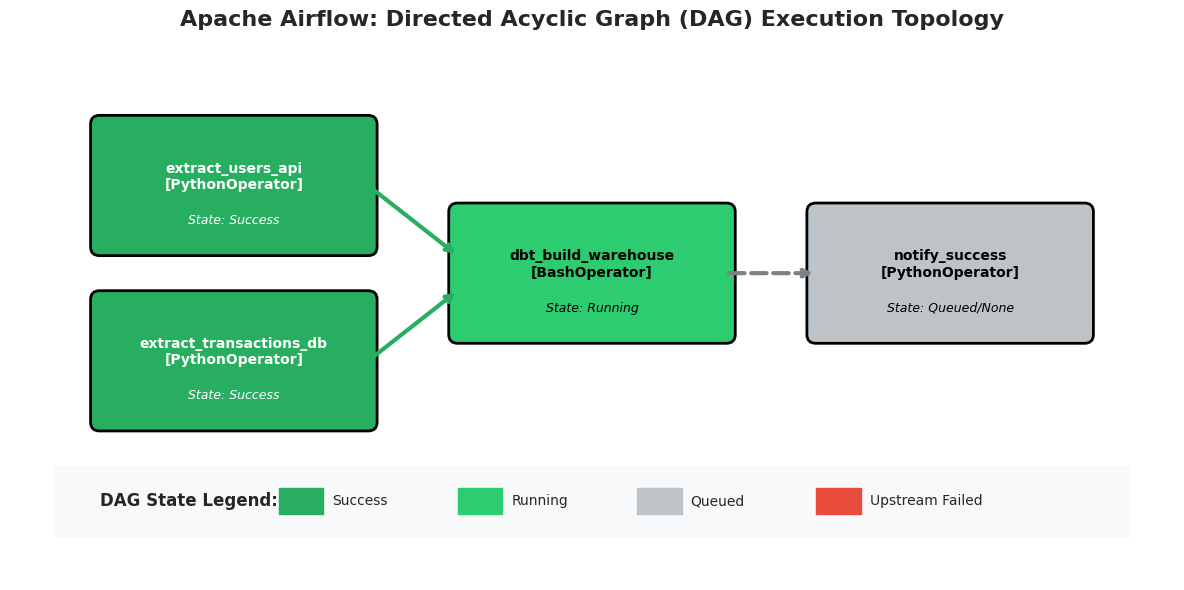

In [9]:
# Visualizing the Airflow DAG Topology
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Apache Airflow: Directed Acyclic Graph (DAG) Execution Topology", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Node Coordinates and Colors (Simulating Airflow State)
# Success = Dark Green, Running = Light Green, Queued = Gray
nodes = {
    "extract_users_api\n[PythonOperator]": (2, 4, "#27ae60", "white", "Success"),
    "extract_transactions_db\n[PythonOperator]": (2, 2, "#27ae60", "white", "Success"),
    "dbt_build_warehouse\n[BashOperator]": (6, 3, "#2ecc71", "black", "Running"),
    "notify_success\n[PythonOperator]": (10, 3, "#bdc3c7", "black", "Queued/None")
}

# Draw Nodes
for name, (x, y, color, text_color, state) in nodes.items():
    rect = patches.FancyBboxPatch((x-1.5, y-0.7), 3.0, 1.4, boxstyle="round,pad=0.1", 
                                 linewidth=2, edgecolor='black', facecolor=color, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y + 0.1, name, color=text_color, fontweight='bold', ha='center', va='center', fontsize=10, zorder=4)
    
    # Add State Badge
    badge_color = 'white' if color == '#27ae60' else 'black'
    ax.text(x, y - 0.4, f"State: {state}", color=badge_color, style='italic', ha='center', va='center', fontsize=9, zorder=4)

# 2. Draw Directed Edges (The Dependencies)
# Users -> dbt
ax.annotate("", xy=(4.5, 3.2), xytext=(3.5, 4.0), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
# Txns -> dbt
ax.annotate("", xy=(4.5, 2.8), xytext=(3.5, 2.0), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
# dbt -> Notify
ax.annotate("", xy=(8.5, 3.0), xytext=(7.5, 3.0), arrowprops=dict(arrowstyle="->", lw=3, color="gray", linestyle="dashed"))

# 3. Add Legend / Legend Box
legend_box = patches.Rectangle((0, 0), 12, 0.8, fill=True, color='#f8f9fa', edgecolor='black', linewidth=1)
ax.add_patch(legend_box)
ax.text(0.5, 0.4, "DAG State Legend:", fontweight='bold', va='center')

# Legend items
ax.add_patch(patches.Rectangle((2.5, 0.25), 0.5, 0.3, fill=True, color='#27ae60', edgecolor='black'))
ax.text(3.1, 0.4, "Success", va='center', fontsize=10)

ax.add_patch(patches.Rectangle((4.5, 0.25), 0.5, 0.3, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(5.1, 0.4, "Running", va='center', fontsize=10)

ax.add_patch(patches.Rectangle((6.5, 0.25), 0.5, 0.3, fill=True, color='#bdc3c7', edgecolor='black'))
ax.text(7.1, 0.4, "Queued", va='center', fontsize=10)

ax.add_patch(patches.Rectangle((8.5, 0.25), 0.5, 0.3, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(9.1, 0.4, "Upstream Failed", va='center', fontsize=10)

plt.xlim(-0.5, 12.5)
plt.ylim(-0.5, 5.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Apache Airflow like **The Conductor of a Symphony Orchestra**:

* **cron (The Metronome)**: A metronome just ticks blindly. If the violinist breaks a string and has to stop playing, the metronome doesn't care. It keeps ticking, the trumpets start blaring exactly on minute 2, and the entire symphony sounds like chaotic garbage.
* **Airflow (The Conductor)**: The Conductor (Airflow) stands at the podium and controls the flow of state. The Conductor knows the sheet music (The DAG Topology). The Conductor knows that the trumpets (dbt) *cannot* begin playing until the violins (Python extraction) have finished their intro section.
* If the violinist drops their bow, the Conductor physically stops the trumpets from coming in. The Conductor tells the violinist to retry (Retry Logic). Once the violins finally finish their section successfully, the Conductor points the baton at the trumpets, transferring the state, and the symphony proceeds flawlessly.